In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os,glob
import re
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/func')

from prepare_img_utils import *
from utils import get_paths

def get_record(s):
    return {
        'filename':s.get('filename'),
        'height': s.get('height'),
        'width': s.get('width'), 
        'ox': s.get('anchoring')[0], 
        'oy': s.get('anchoring')[1],
        'oz': s.get('anchoring')[2],
        'ux': s.get('anchoring')[3],
        'uy': s.get('anchoring')[4],
        'uz': s.get('anchoring')[5], 
        'vx': s.get('anchoring')[6], 
        'vy': s.get('anchoring')[7],
        'vz': s.get('anchoring')[8],
    }

HOMEDIR = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/'
paths = get_paths()
print(paths.keys())

dict_keys(['code_root', 'data_root', 'package_root'])


In [2]:
scaling_factor=1/32; 
all_file_path = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/image_xml/*.jpg'
for f in glob.glob(all_file_path):
    print(os.path.basename(f).split('cell_img_')[1].split('.')[0])   # btw these images are 25um resolutions

MouseC_C2
MouseC_C3
MouseC_C4
MouseC_C5
MouseEg_B3
MouseEg_Eg1
MouseEg_Eg2
MouseEg_Eg3
MouseEg_Eg4
MouseEg_Eg5
MouseF_F1
MouseF_F2
MouseF_F3
MouseF_F4
MouseZM_ZM0
MouseZM_ZM1
MouseZM_ZM2
MouseZM_ZM3
MouseZM_ZM4
MouseZM_ZM5p1
MouseZM_ZM5p2
MouseZM_ZM6p1
MouseZM_ZM7p1
MouseZM_ZM7p2


In [3]:
slicename_all = [os.path.basename(f).split('cell_img_')[1].split('.')[0] for f in glob.glob(all_file_path)]
slicename_all.sort()
print(slicename_all, len(slicename_all))

['MouseC_C2', 'MouseC_C3', 'MouseC_C4', 'MouseC_C5', 'MouseEg_B3', 'MouseEg_Eg1', 'MouseEg_Eg2', 'MouseEg_Eg3', 'MouseEg_Eg4', 'MouseEg_Eg5', 'MouseF_F1', 'MouseF_F2', 'MouseF_F3', 'MouseF_F4', 'MouseZM_ZM0', 'MouseZM_ZM1', 'MouseZM_ZM2', 'MouseZM_ZM3', 'MouseZM_ZM4', 'MouseZM_ZM5p1', 'MouseZM_ZM5p2', 'MouseZM_ZM6p1', 'MouseZM_ZM7p1', 'MouseZM_ZM7p2'] 24


In [4]:
reg_file_path = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/registered/'

In [5]:

genecounts_all = dict()
reg_points_all = dict()
for name in slicename_all:  
    
    reg_points_path = reg_file_path + f'registered_{name}.csv'
    df = pd.read_csv(reg_points_path, on_bad_lines='skip')[['neuron_id','x_CCF','y_CCF','z_CCF']]    
    reg_points_all[name] = df
    
    thisdircheck = (paths['data_root'] + name + '/' + 'analyzed_data/*/region_*/')    
    alltifregions = np.array([[s for s in m.split('/') if 'region' in s][0] for m in glob.glob(thisdircheck + '/images/*.tif')])
    values, counts = np.unique(alltifregions, return_counts=True)
    region_chosen = values[np.argmax(counts)]
    thisdircheck = (paths['data_root'] + name + '/' + f'analyzed_data/*/{region_chosen}/')

    cell_loc_path = glob.glob(thisdircheck + 'cell_metadata.csv')[0]
    countmatrix_path = glob.glob(thisdircheck+'cell_by_gene.csv')[0]
    count_mtx = pd.read_csv(countmatrix_path, index_col=0).sort_index()
    genecounts_all[name] = count_mtx

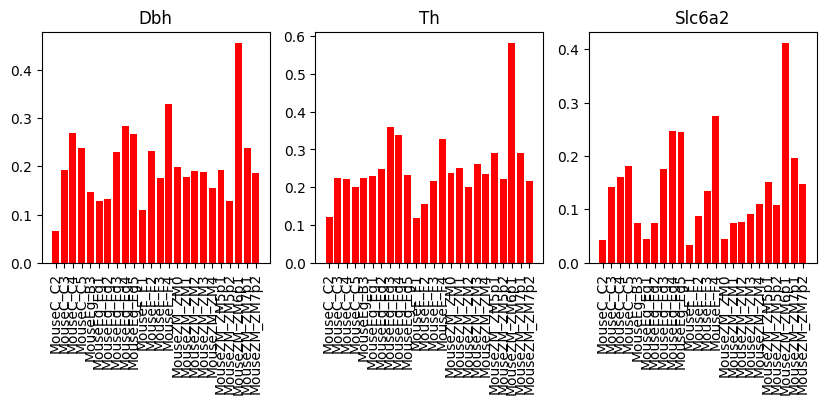

In [6]:
markergenes = ['Dbh', 'Th', 'Slc6a2']
plt.figure(figsize = (10, 3))
for k,g in enumerate(markergenes):
    plt.subplot(1,3,k+1)
    for k, v in genecounts_all.items():
        expr = np.array(v[g]).flatten()
        plt.bar(k,np.mean(expr), color = 'red')
    plt.xticks(rotation=90);
    plt.title(g)
    


In [7]:
out_df_gene = []
out_df_loc = []
for p,name in enumerate(slicename_all):
    totalexpression = np.prod(np.array([genecounts_all[name][k].values for k in markergenes]), 0)
     # Boolean to indicaet if all three marker genes have to be expressed  in this cell!
    keptcellID = totalexpression>10   # if this is zero, we will have 7k cells. if this is 10 then we will have 5.4k cells
    
    # for gene counts
    foo_df = genecounts_all[name].iloc[keptcellID] 
    foo_df= foo_df.assign(slicename=list(np.repeat(name,(keptcellID).sum())))
    out_df_gene.append(foo_df)
    
    # for locations
    foo_df = reg_points_all[name].iloc[keptcellID]
    foo_df.index = foo_df['neuron_id']
    out_df_loc.append(foo_df)
    
out_df_gene = pd.concat(out_df_gene)    
out_df_loc = pd.concat(out_df_loc)    
out_df_gene.index.name = 'neuron_id'

In [8]:
df = pd.concat((out_df_loc,out_df_gene),axis=1)

In [9]:
import anndata as ad
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]

df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")


In [11]:

allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    

In [12]:
dictkeys = list(['MouseC', 'MouseEg', 'MouseF', 'MouseZM'])
dictvals = list(['M', 'F', 'F', 'M'])
mouse_sex_map = {key: value for key, value in zip(dictkeys, dictvals)}

adata_mer.obsm["spatial"] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.raw = adata_mer.copy()
adata_mer.obs['mouse_name'] = section_identifier_highlevel
adata_mer.obs["slicename"] = adata_mer.obs["slicename"].astype("category")
adata_mer.obs['mouse_sex'] = adata_mer.obs['mouse_name'].map(mouse_sex_map)

In [13]:
markergenesid = np.array([np.where(adata_mer.var_names==m)[0][0] for m in markergenes])
totalexpression = np.prod(adata_mer.X[:,markergenesid], 1)


# Boolean to indicaet if all three marker genes have to be expre
keptcellID = totalexpression>0
adata_mer = adata_mer[keptcellID]
adata_mer.shape

(5473, 315)

# check doublet

In [15]:
from sklearn.neighbors import NearestNeighbors

# --- get spatial XY ---
def get_spatial_xy(adata, obsm_key="spatial"):
    if obsm_key in adata.obsm:
        return np.asarray(adata.obsm[obsm_key])[:, :2]
    for xk, yk in [("x","y"), ("X","Y"), ("center_x","center_y")]:
        if xk in adata.obs.columns and yk in adata.obs.columns:
            return adata.obs[[xk, yk]].to_numpy()
    raise KeyError("No spatial coordinates found in adata.obsm['spatial'] or common obs columns.")

XY = get_spatial_xy(adata_mer)

# --- compute nearest-neighbor within each slicename ---
nn_dist = np.full(adata_mer.n_obs, np.nan, dtype=float)
nn_idx  = np.full(adata_mer.n_obs, -1, dtype=int)

for s, ix in adata_mer.obs.groupby("slicename").indices.items():
    ix = np.asarray(ix, dtype=int)
    if ix.size < 2:
        continue

    nbrs = NearestNeighbors(n_neighbors=2, algorithm="kd_tree").fit(XY[ix])
    d, j = nbrs.kneighbors(XY[ix])
    nn_dist[ix] = d[:, 1]
    nn_idx[ix]  = ix[j[:, 1]]  # map back to global indices

adata_mer.obs["nn_dist_in_slice"] = nn_dist
adata_mer.obs["nn_neighbor_in_slice"] = adata_mer.obs_names.to_numpy()[nn_idx]

# --- flag too-close within each slice using per-slice percentile cutoff ---
p = 0.5  # smallest 0.5% within each slice
too_close = np.zeros(adata_mer.n_obs, dtype=bool)
slice_cutoff = {}

for s, ix in adata_mer.obs.groupby("slicename").indices.items():
    ix = np.asarray(ix, dtype=int)
    d = nn_dist[ix]
    d = d[np.isfinite(d)]
    if d.size == 0:
        continue
    c = np.percentile(d, p)
    slice_cutoff[s] = c
    too_close[ix] = nn_dist[ix] <= c

adata_mer.obs["nn_too_close_in_slice"] = too_close

print("Flagged cells:", int(too_close.sum()), "/", adata_mer.n_obs)
print("Example slice cutoffs (nn_dist) for p =", p)
print(pd.Series(slice_cutoff).sort_values().head(10))

# --- table of closest pairs to inspect ---
pairs = pd.DataFrame({
    "slicename": adata_mer.obs["slicename"].values,
    "cell": adata_mer.obs_names.values,
    "nearest": adata_mer.obs["nn_neighbor_in_slice"].values,
    "nn_dist": adata_mer.obs["nn_dist_in_slice"].values,
    "too_close": adata_mer.obs["nn_too_close_in_slice"].values,
}).sort_values(["slicename", "nn_dist"])

pairs.head(30)


Flagged cells: 52 / 5473
Example slice cutoffs (nn_dist) for p = 0.5
MouseC_C2      0.000367
MouseEg_Eg5    0.000871
MouseC_C5      0.002023
MouseC_C4      0.002951
MouseC_C3      0.003410
MouseF_F2      0.004688
MouseF_F3      0.005514
MouseEg_Eg4    0.008354
MouseEg_Eg2    0.012725
MouseEg_Eg3    0.013006
dtype: float64


/scratch/fast/11105015/ipykernel_1727067/2421824356.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for s, ix in adata_mer.obs.groupby("slicename").indices.items():
/scratch/fast/11105015/ipykernel_1727067/2421824356.py:28: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mer.obs["nn_dist_in_slice"] = nn_dist
/scratch/fast/11105015/ipykernel_1727067/2421824356.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for s, ix in adata_mer.obs.groupby("slicename").indices.items():


,slicename,cell,nearest,nn_dist,too_close
32,MouseC_C2,154953946534573099232703817795374086850,80791432596433225773242813938917157099,0.000367,True
156,MouseC_C2,80791432596433225773242813938917157099,154953946534573099232703817795374086850,0.000367,True
91,MouseC_C2,272749008411691964107009425223062771147,58121079432002842196662881860275959939,0.000482,False
146,MouseC_C2,58121079432002842196662881860275959939,272749008411691964107009425223062771147,0.000482,False
44,MouseC_C2,176284234489824111755220999571150893551,154953946534573099232703817795374086850,0.002136,False
6,MouseC_C2,115821653769956438853796122317914919172,32622756943643163230879470390107958092,0.002954,False
125,MouseC_C2,32622756943643163230879470390107958092,115821653769956438853796122317914919172,0.002954,False
35,MouseC_C2,161607618123422334063661868687834516718,183113507272200686890428382965018816219,0.004827,False
52,MouseC_C2,183113507272200686890428382965018816219,161607618123422334063661868687834516718,0.004827,False
19,MouseC_C2,136902804977786671475756914735264075594,148205882243229272441483277970518915538,0.006450,False


In [16]:
d = adata_mer.obs["nn_dist_in_slice"].to_numpy()
print("nn_dist == 0:", np.sum(d == 0))
print("nn_dist < 1e-6:", np.sum(d < 1e-6))
print("nn_dist < 1e-5:", np.sum(d < 1e-5))

nn_dist == 0: 0
nn_dist < 1e-6: 0
nn_dist < 1e-5: 0


In [17]:
XY = np.asarray(adata_mer.obsm["spatial"])[:, :2]
pairs = pd.DataFrame({
    "slicename": adata_mer.obs["slicename"].values,
    "cell": adata_mer.obs_names.values,
    "nearest": adata_mer.obs["nn_neighbor_in_slice"].values,
    "nn_dist": adata_mer.obs["nn_dist_in_slice"].values,
    "too_close": adata_mer.obs["nn_too_close_in_slice"].values,
    "x": XY[:,0],
    "y": XY[:,1],
})

pairs_small = pairs.sort_values("nn_dist").head(30).copy()
pairs_small["nearest_x"] = pairs_small["nearest"].map(dict(zip(pairs["cell"], pairs["x"])))
pairs_small["nearest_y"] = pairs_small["nearest"].map(dict(zip(pairs["cell"], pairs["y"])))
pairs_small

,slicename,cell,nearest,nn_dist,too_close,x,y,nearest_x,nearest_y
32,MouseC_C2,154953946534573099232703817795374086850,80791432596433225773242813938917157099,0.000367,True,410.127128,246.508194,410.127109,246.507828
156,MouseC_C2,80791432596433225773242813938917157099,154953946534573099232703817795374086850,0.000367,True,410.127109,246.507828,410.127128,246.508194
146,MouseC_C2,58121079432002842196662881860275959939,272749008411691964107009425223062771147,0.000482,False,404.800006,145.951069,404.799980,145.950588
91,MouseC_C2,272749008411691964107009425223062771147,58121079432002842196662881860275959939,0.000482,False,404.799980,145.950588,404.800006,145.951069
2427,MouseEg_Eg5,65177851918021182425378876083104675737,5805323114010318383098349869914577339,0.000503,True,426.844140,194.849056,426.844642,194.849084
2419,MouseEg_Eg5,5805323114010318383098349869914577339,65177851918021182425378876083104675737,0.000503,True,426.844642,194.849084,426.844140,194.849056
2117,MouseEg_Eg5,163213587340269563477218910052014290521,277138785729204059558742120161815391638,0.000871,True,429.662045,176.807113,429.661211,176.806862
2289,MouseEg_Eg5,277138785729204059558742120161815391638,163213587340269563477218910052014290521,0.000871,True,429.661211,176.806862,429.662045,176.807113
395,MouseC_C4,115695158721492898042687072174855744451,227545419863799153881326092803072416354,0.001413,True,419.994918,164.469292,419.993753,164.470092
557,MouseC_C4,227545419863799153881326092803072416354,115695158721492898042687072174855744451,0.001413,True,419.993753,164.470092,419.994918,164.469292


In [18]:
candidate_cols = ["n_counts", "total_counts", "nCount_RNA", "UMI", "transcript_counts"]
count_col = next((c for c in candidate_cols if c in adata_mer.obs.columns), None)

flag = adata_mer.obs["nn_too_close_in_slice"].to_numpy()

if count_col is None:
    print("No obvious count column found in adata_mer.obs. Available cols example:",
          list(adata_mer.obs.columns)[:20])
else:
    import numpy as np
    print("Using count column:", count_col)
    print("median counts (flagged):", np.median(adata_mer.obs.loc[flag, count_col]))
    print("median counts (others): ", np.median(adata_mer.obs.loc[~flag, count_col]))

No obvious count column found in adata_mer.obs. Available cols example: ['slicename', 'x_CCF', 'y_CCF', 'z_CCF', 'mouse_name', 'mouse_sex', 'nn_dist_in_slice', 'nn_neighbor_in_slice', 'nn_too_close_in_slice']


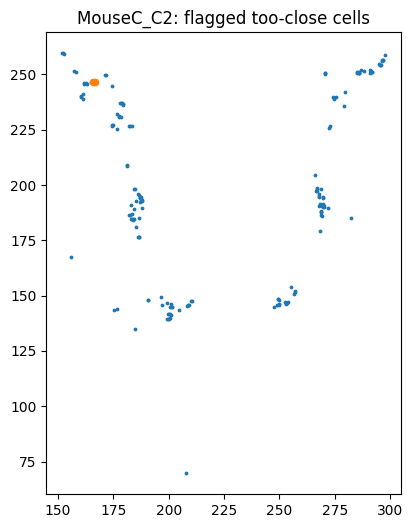

In [19]:

slice_name = "MouseC_C2"
sub = adata_mer.obs["slicename"].astype(str).values == slice_name
flag = adata_mer.obs["nn_too_close_in_slice"].to_numpy()

XY = np.asarray(adata_mer.obsm["spatial"])[:, [2,1]]

plt.figure(figsize=(6,6))
plt.scatter(XY[sub & ~flag,0], XY[sub & ~flag,1], s=3)
plt.scatter(XY[sub & flag,0],  XY[sub & flag,1],  s=20)
plt.gca().set_aspect("equal")
plt.title(f"{slice_name}: flagged too-close cells")
plt.show()

In [22]:

um_per_unit = 25.0  # confirmed: 25 µm per coordinate unit
cutoff_um = 0.1
cutoff_units = cutoff_um / um_per_unit  # 1 µm -> 0.04 units

d = adata_mer.obs["nn_dist_in_slice"].to_numpy()
flag = np.isfinite(d) & (d <= cutoff_units)

print(f"Resolution: {um_per_unit} µm/unit")
print(f"Threshold:  {cutoff_um} µm  (= {cutoff_units:.4f} units)")
print(f"Flagged:    {int(flag.sum())} / {adata_mer.n_obs}")

# per-slice counts
per_slice = (
    adata_mer.obs.assign(flag=flag)
    .groupby("slicename")["flag"]
    .agg(n_flagged="sum", n_cells="count")
)
per_slice["pct_flagged"] = 100 * per_slice["n_flagged"] / per_slice["n_cells"]
per_slice = per_slice.sort_values(["n_flagged", "pct_flagged"], ascending=False)

per_slice.head(20)

Resolution: 25.0 µm/unit
Threshold:  0.1 µm  (= 0.0040 units)
Flagged:    31 / 5473


/scratch/fast/11105015/ipykernel_1727067/2582602390.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("slicename")["flag"]


,n_flagged,n_cells,pct_flagged
slicename,,,
MouseEg_Eg5,12,450,2.666667
MouseC_C2,7,173,4.046243
MouseC_C5,4,300,1.333333
MouseC_C4,4,389,1.028278
MouseC_C3,2,208,0.961538
MouseEg_Eg4,2,378,0.529101
MouseEg_B3,0,120,0.000000
MouseEg_Eg1,0,70,0.000000
MouseEg_Eg2,0,69,0.000000
